# Brazilian E-commerce Review Sentiment Analysis
### Enhanced with models from recent Bangla / multilingual sentiment papers

This notebook focuses **only on review sentiment classification** (freight-cost reconstruction has been removed).

We keep the original Olist Portuguese review pipeline and add the model families used in:
- **Sarker et al. (STI 2022)** – LSTM, BiLSTM, CNN-LSTM, CNN-BiLSTM + m-BERT / XLM-R
- **Shanto et al. (IJIEEB 2023)** – Logistic Regression, Random Forest, SVM (linear & RBF), Multinomial NB, KNN, SGD, Decision Tree with TF-IDF / CountVectorizer (uni/bi-gram)
- **Sarowar et al. (I2CT 2019)** – Stop-word filtering + TF-IDF + hybrid KNN-clustering / SVM pipeline

**What's new in this revision**
1. **CNN-BiLSTM** deep-learning model (added alongside LSTM / BiLSTM / CNN-LSTM).
2. **Multiple transformer fine-tunes** — XLM-R, m-BERT, and a Portuguese-specific BERT (BERTimbau), in addition to the original DistilBERT-multilingual baseline.
3. **Pretrained Portuguese fastText embeddings** (`cc.pt.300.vec`) used to initialize the Keras `Embedding` layer, with an automatic fallback to a learned embedding if the vectors can't be downloaded.
4. **Hybrid KNN-clustering + SVM** classifier, reproducing the Sarowar et al. (2019) approach: partition the training data into clusters, train one SVM per cluster, route new samples to the nearest cluster at inference time.
5. **RBF-kernel SVM** added to the classical model grid (subsampled — RBF SVM training cost grows faster than linear with data size).
6. A **data-leakage guard**: exact-duplicate review texts are dropped before the train/test split, and an assertion confirms zero text overlap between the two partitions.
7. All comparison tables are de-duplicated by approach name so re-running cells never produces repeated rows.

**Why these tasks are high-confidence:** sentiment is already fully determined by the text the customer wrote; there is no future event to forecast. Expect binary accuracy well above 80–90 % with a good model.

**Environment:** Kaggle Notebook, GPU recommended (2× T4 or similar). Running every transformer fine-tune and the fastText download in one pass is heavy — trim the `FT_MODEL_NAMES` list in section 5 if you're short on GPU time / internet access.


In [5]:
import os, sys, glob, warnings, json, subprocess, time
warnings.filterwarnings('ignore')
print("Python:", sys.version)
try:
    import subprocess as sp
    print(sp.check_output(["nvidia-smi"], text=True)[:800])
except Exception as e:
    print("nvidia-smi not available:", e)


Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
Wed Aug 19 05:52:48 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.159.04             Driver Version: 580.159.04     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   56C    P8             10


In [6]:
def pip_install(pkg):
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "--break-system-packages", pkg], check=False)

for pkg in ["xgboost", "transformers", "torch", "scikit-learn", "joblib", "matplotlib", "seaborn"]:
    try:
        __import__(pkg if pkg != "scikit-learn" else "sklearn")
    except ImportError:
        pip_install(pkg)

# Keras / TF for LSTM family (optional but useful)
try:
    import tensorflow as tf
    print("TensorFlow:", tf.__version__)
except ImportError:
    pip_install("tensorflow")
    import tensorflow as tf
    print("TensorFlow:", tf.__version__)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC, SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix,
                             f1_score, precision_score, recall_score)
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.model_selection import StratifiedShuffleSplit
from collections import Counter
import joblib
import torch
print("CUDA available:", torch.cuda.is_available())


TensorFlow: 2.20.0
CUDA available: True


## 1. Load Data

In [7]:
def find_csv(keywords, exclude=None):
    if isinstance(keywords, str):
        keywords = [keywords]
    all_csvs = glob.glob("/kaggle/input/**/*.csv", recursive=True)
    if not all_csvs:
        # local fallback for non-Kaggle runs
        all_csvs = glob.glob("**/*.csv", recursive=True)
    for kw in keywords:
        for path in all_csvs:
            fname = os.path.basename(path).lower()
            if kw in fname and (exclude is None or exclude not in fname):
                return path
    raise FileNotFoundError(f"No CSV found for keywords={keywords}")

FILES = {
    "customers":            find_csv(["customer", "cusomter", "custome"]),
    "order_items":          find_csv("order_item"),
    "orders":               find_csv("orders"),
    "reviews":              find_csv("review"),
    "products":             find_csv("product", exclude="category"),
    "sellers":              find_csv("seller"),
    "category_translation": find_csv("category_name_translation"),
}
for k, v in FILES.items():
    print(f"{k:22s} -> {os.path.basename(v)}")

customers = pd.read_csv(FILES["customers"])
orders = pd.read_csv(FILES["orders"], parse_dates=["order_purchase_timestamp"])
order_items = pd.read_csv(FILES["order_items"])
reviews = pd.read_csv(FILES["reviews"])
products = pd.read_csv(FILES["products"])
sellers = pd.read_csv(FILES["sellers"])
cat_trans = pd.read_csv(FILES["category_translation"])
print("loaded ok")
print("Reviews shape:", reviews.shape)


customers              -> cusomters_dataset.csv
order_items            -> order_items_dataset.csv
orders                 -> orders_dataset.csv
reviews                -> order_reviews_dataset.csv
products               -> products_dataset.csv
sellers                -> sellers_dataset.csv
category_translation   -> product_category_name_translation.csv
loaded ok
Reviews shape: (98410, 8)


## 2. Build the Text Dataset
Only reviews with actual written text can be sentiment-classified.  
Score 3 (neutral) is excluded from the binary target — it is genuinely ambiguous, and dropping it keeps accuracy numbers honest.


In [8]:
reviews_text = reviews.dropna(subset=["review_comment_message"]).copy()
reviews_text["review_comment_message"] = reviews_text["review_comment_message"].str.strip()
reviews_text = reviews_text[reviews_text["review_comment_message"].str.len() > 0]

# combine title + body (title is often very informative in Olist)
reviews_text["full_text"] = (
    reviews_text["review_comment_title"].fillna("") + " " + reviews_text["review_comment_message"]
).str.strip()

reviews_text = reviews_text[reviews_text["review_score"] != 3].copy()
reviews_text["sentiment"] = np.where(reviews_text["review_score"] >= 4, "positive", "negative")
reviews_text["label"] = (reviews_text["sentiment"] == "positive").astype(int)

print(f"Reviews with text (excluding neutral score=3): {len(reviews_text):,}")

# --- Data-leakage guard, part 1: drop duplicate review texts -------------
# The same review text can legitimately appear more than once in Olist
# (copy-pasted reviews, templated complaints, etc.). If we don't dedupe
# before splitting, an identical text can land in *both* train and test,
# which lets a model "memorize" it rather than generalize — an easy way
# to get inflated accuracy that won't hold up on new reviews.
n_before = len(reviews_text)
reviews_text = reviews_text.drop_duplicates(subset=["full_text"]).copy()
n_after = len(reviews_text)
print(f"Dropped {n_before - n_after:,} duplicate review texts "
      f"({(n_before - n_after) / n_before:.1%} of the dataset).")

print(reviews_text["sentiment"].value_counts())
print(reviews_text["sentiment"].value_counts(normalize=True).round(3))

# train / test split (stratified)
X = reviews_text["full_text"].values
y = reviews_text["label"].values
X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X, y, reviews_text.index, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {len(X_train):,}  |  Test: {len(X_test):,}")

# --- Data-leakage guard, part 2: verify zero text overlap -----------------
overlap = set(X_train) & set(X_test)
assert len(overlap) == 0, (
    f"Data leakage detected: {len(overlap)} identical review texts appear "
    f"in both train and test!"
)
print("Leakage check passed: no identical review text is shared between train and test.")


Reviews with text (excluding neutral score=3): 37,113
Dropped 3,642 duplicate review texts (9.8% of the dataset).
sentiment
positive    23013
negative    10458
Name: count, dtype: int64
sentiment
positive    0.688
negative    0.312
Name: proportion, dtype: float64
Train: 26,776  |  Test: 6,695
Leakage check passed: no identical review text is shared between train and test.


## 3. Classical Machine-Learning Suite
(Inspired by **Shanto et al. IJIEEB 2023** and **Sarowar et al. 2019**)

Feature extractors:
- TF-IDF (unigram + bigram)
- CountVectorizer (unigram + bigram)

Classifiers:
- Logistic Regression, Random Forest, Linear SVM, **RBF SVM** (subsampled),
  Multinomial NB, KNN, Decision Tree, SGD, **Hybrid KNN-cluster + SVM** (Sarowar et al. 2019 style)

### 3.1 Hybrid KNN-clustering + SVM (Sarowar et al. 2019)
The paper's "proposed approach" isn't a single classifier — it's an ensemble:
1. Cluster the *training* data (here with k-means, "KNN clustering" in the paper's loose terminology) into `n_clusters` groups.
2. Train one SVM per cluster on only that cluster's data — smaller, more homogeneous training sets, so each SVM should be faster and sometimes more accurate.
3. At inference time, route each new sample to its nearest cluster centroid, then classify with that cluster's SVM.

This is implemented below as a small scikit-learn-compatible estimator so it can slot into the same evaluation loop as every other classifier.


In [9]:
class HybridKNNSVM(BaseEstimator, ClassifierMixin):
    """Reimplementation of the KNN-clustering + SVM ensemble from
    Sarowar et al. (2019, I2CT): partition the training data into
    `n_clusters` clusters (k-means), train one SVM per cluster, and at
    inference time route each sample to its nearest cluster centroid
    before asking that cluster's SVM for a prediction.
    """

    def __init__(self, n_clusters=3, svm_kernel="linear", C=1.0, random_state=42):
        self.n_clusters = n_clusters
        self.svm_kernel = svm_kernel
        self.C = C
        self.random_state = random_state

    def fit(self, X, y):
        y = np.asarray(y)
        self.classes_ = np.unique(y)
        self.kmeans_ = KMeans(
            n_clusters=self.n_clusters, random_state=self.random_state, n_init=10
        )
        cluster_ids = self.kmeans_.fit_predict(X)

        self.svms_ = {}
        for c in range(self.n_clusters):
            mask = cluster_ids == c
            # guard against tiny / single-class clusters: fall back to
            # fitting that cluster's SVM on the full training set instead.
            if mask.sum() < 10 or len(np.unique(y[mask])) < 2:
                Xc, yc = X, y
            else:
                Xc, yc = X[mask], y[mask]
            clf = SVC(
                kernel=self.svm_kernel, C=self.C, probability=True,
                class_weight="balanced", random_state=self.random_state
            )
            clf.fit(Xc, yc)
            self.svms_[c] = clf
        return self

    def predict(self, X):
        cluster_ids = self.kmeans_.predict(X)
        preds = np.zeros(X.shape[0], dtype=self.classes_.dtype)
        for c, clf in self.svms_.items():
            mask = cluster_ids == c
            if mask.any():
                preds[mask] = clf.predict(X[mask])
        return preds

    def predict_proba(self, X):
        cluster_ids = self.kmeans_.predict(X)
        proba = np.zeros((X.shape[0], len(self.classes_)))
        for c, clf in self.svms_.items():
            mask = cluster_ids == c
            if mask.any():
                proba[mask] = clf.predict_proba(X[mask])
        return proba


In [10]:
vectorizers = {
    "tfidf_uni": TfidfVectorizer(max_features=30000, ngram_range=(1, 1), min_df=2, max_df=0.95),
    "tfidf_bi":  TfidfVectorizer(max_features=30000, ngram_range=(1, 2), min_df=2, max_df=0.95),
    "count_uni": CountVectorizer(max_features=30000, ngram_range=(1, 1), min_df=2, max_df=0.95),
    "count_bi":  CountVectorizer(max_features=30000, ngram_range=(1, 2), min_df=2, max_df=0.95),
}

classifiers = {
    "LogisticRegression": LogisticRegression(max_iter=1000, class_weight="balanced", n_jobs=-1),
    "RandomForest":       RandomForestClassifier(n_estimators=200, class_weight="balanced", n_jobs=-1, random_state=42),
    "LinearSVM":          LinearSVC(class_weight="balanced", max_iter=2000, random_state=42),
    "RBFSVM":             SVC(kernel="rbf", C=1.0, class_weight="balanced", probability=True, random_state=42),
    "MultinomialNB":      MultinomialNB(),
    "SGD":                SGDClassifier(loss="log_loss", class_weight="balanced", max_iter=1000, random_state=42),
    "DecisionTree":       DecisionTreeClassifier(class_weight="balanced", max_depth=30, random_state=42),
    "KNN":                KNeighborsClassifier(n_neighbors=7, n_jobs=-1),
    "HybridKNN_SVM":      HybridKNNSVM(n_clusters=3, svm_kernel="linear", C=1.0, random_state=42),
}
# sanity check: no duplicate classifier / vectorizer names (would silently
# overwrite an entry and re-run the same model twice)
assert len(classifiers) == len(set(classifiers)), "Duplicate classifier name detected!"
assert len(vectorizers) == len(set(vectorizers)), "Duplicate vectorizer name detected!"

# RBF SVM and the hybrid KNN/SVM ensemble are both O(n^2)-ish to train, and
# KNN inference is slow on very large training sets -> subsample all three
# for speed. Everything else trains on the full training data.
SUBSAMPLE_FOR = {"KNN", "RBFSVM", "HybridKNN_SVM"}
SUBSAMPLE_SIZE = 12000

results = []
best_model = None
best_score = -1
best_name = None
best_vec_name = None

for vec_name, vec in vectorizers.items():
    print(f"\n=== Vectorizer: {vec_name} ===")
    Xtr = vec.fit_transform(X_train)
    Xte = vec.transform(X_test)
    for clf_name, clf in classifiers.items():
        t0 = time.time()
        if clf_name in SUBSAMPLE_FOR and Xtr.shape[0] > SUBSAMPLE_SIZE:
            # fit on a stratified subsample for speed (train-only data, no leakage)
            sss = StratifiedShuffleSplit(n_splits=1, train_size=SUBSAMPLE_SIZE, random_state=42)
            sub_idx, _ = next(sss.split(Xtr, y_train))
            clf.fit(Xtr[sub_idx], y_train[sub_idx])
        else:
            clf.fit(Xtr, y_train)
        pred = clf.predict(Xte)
        acc = accuracy_score(y_test, pred)
        f1  = f1_score(y_test, pred, average="weighted")
        elapsed = time.time() - t0
        results.append({
            "vectorizer": vec_name, "classifier": clf_name,
            "accuracy": acc, "f1_weighted": f1, "seconds": round(elapsed, 1)
        })
        print(f"  {clf_name:20s}  acc={acc:.4f}  f1={f1:.4f}  ({elapsed:.1f}s)")
        if f1 > best_score:
            best_score = f1
            best_model = (vec, clf)
            best_name = clf_name
            best_vec_name = vec_name

classical_df = pd.DataFrame(results).sort_values("f1_weighted", ascending=False)
# de-dup safety net: if this cell is ever re-run and appended to an existing
# `results` list instead of a fresh one, keep only the best run per config.
classical_df = classical_df.drop_duplicates(subset=["vectorizer", "classifier"], keep="first")
print("\n--- Top 10 classical configurations ---")
print(classical_df.head(10).to_string())

print(f"\nBest classical: {best_vec_name} + {best_name}  (F1={best_score:.4f})")
# re-fit best on full train for later use
best_vec, best_clf = best_model
Xtr_best = best_vec.fit_transform(X_train)
best_clf.fit(Xtr_best, y_train)
pred_best_classical = best_clf.predict(best_vec.transform(X_test))
print(classification_report(y_test, pred_best_classical, target_names=["negative", "positive"]))



=== Vectorizer: tfidf_uni ===
  LogisticRegression    acc=0.9219  f1=0.9232  (1.7s)
  RandomForest          acc=0.9158  f1=0.9164  (19.8s)
  LinearSVM             acc=0.9231  f1=0.9240  (0.1s)
  RBFSVM                acc=0.9276  f1=0.9284  (50.7s)
  MultinomialNB         acc=0.9092  f1=0.9095  (0.0s)
  SGD                   acc=0.9180  f1=0.9194  (0.0s)
  DecisionTree          acc=0.8738  f1=0.8753  (2.1s)
  KNN                   acc=0.7340  f1=0.6638  (2.4s)
  HybridKNN_SVM         acc=0.9171  f1=0.9179  (24.3s)

=== Vectorizer: tfidf_bi ===
  LogisticRegression    acc=0.9253  f1=0.9265  (1.3s)
  RandomForest          acc=0.9202  f1=0.9208  (43.9s)
  LinearSVM             acc=0.9298  f1=0.9304  (0.1s)
  RBFSVM                acc=0.9289  f1=0.9296  (83.6s)
  MultinomialNB         acc=0.9217  f1=0.9220  (0.0s)
  SGD                   acc=0.9187  f1=0.9202  (0.1s)
  DecisionTree          acc=0.8769  f1=0.8785  (3.9s)
  KNN                   acc=0.7071  f1=0.6109  (2.3s)
  HybridKNN_SVM 

## 4. Pretrained Multilingual Transformers (Zero-shot / Off-the-shelf)
Original notebook used `nlptown/bert-base-multilingual-uncased-sentiment` (1–5 stars).  
We also evaluate a simple inference path with **XLM-RoBERTa** style models (best model in Sarker et al. STI 2022).

Full fine-tuning of XLM-R / m-BERT is possible but heavy; here we keep a practical zero-shot / light inference baseline and a lightweight fine-tune option.


In [11]:
from transformers import pipeline, AutoTokenizer, AutoModelForSequenceClassification
from transformers import Trainer, TrainingArguments
from torch.utils.data import Dataset

SAMPLE_SIZE = min(4000, len(reviews_text))
sample_idx = np.random.RandomState(42).choice(len(reviews_text), SAMPLE_SIZE, replace=False)
sample = reviews_text.iloc[sample_idx].reset_index(drop=True)

# --- 4a. nlptown star model (original) ---
print("Loading nlptown/bert-base-multilingual-uncased-sentiment ...")
sentiment_pipe = pipeline(
    "sentiment-analysis",
    model="nlptown/bert-base-multilingual-uncased-sentiment",
    device=0 if torch.cuda.is_available() else -1,
    truncation=True, max_length=256
)
texts = sample["full_text"].tolist()
results = sentiment_pipe(texts, batch_size=32)
sample["pretrained_stars"] = [int(r["label"][0]) for r in results]
sample["pretrained_sentiment"] = np.where(sample["pretrained_stars"] >= 4, "positive", "negative")
sample["true_binary"] = sample["sentiment"]

exact_star_acc = accuracy_score(sample["review_score"], sample["pretrained_stars"])
binary_acc = accuracy_score(sample["true_binary"], sample["pretrained_sentiment"])
print(f"nlptown exact-star accuracy : {exact_star_acc:.4f}")
print(f"nlptown binary accuracy     : {binary_acc:.4f}")
print(classification_report(sample["true_binary"], sample["pretrained_sentiment"]))


Loading nlptown/bert-base-multilingual-uncased-sentiment ...


config.json:   0%|          | 0.00/953 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/669M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/39.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

nlptown exact-star accuracy : 0.6240
nlptown binary accuracy     : 0.8163
              precision    recall  f1-score   support

    negative       0.64      0.91      0.75      1226
    positive       0.95      0.77      0.85      2774

    accuracy                           0.82      4000
   macro avg       0.80      0.84      0.80      4000
weighted avg       0.86      0.82      0.82      4000



## 5. Fine-tune Multiple Transformer Backbones
We fine-tune several compact/multilingual transformer backbones on a stratified subset so the
notebook stays runnable, mirroring the **m-BERT / XLM-R fine-tuning** approach of Sarker et al.
(STI 2022) plus a Portuguese-specific model:

- `distilbert-base-multilingual-cased` — fast multilingual baseline (kept from the original notebook)
- `xlm-roberta-base` — the best-performing backbone in Sarker et al. (STI 2022)
- `bert-base-multilingual-cased` (m-BERT) — second-best in Sarker et al.
- `neuralmind/bert-base-portuguese-cased` (BERTimbau) — Portuguese-specific BERT, likely to help since our reviews are in Portuguese, not Bangla

Trim `FT_MODEL_NAMES` below if you're short on GPU time — each additional backbone adds several
minutes of fine-tuning.


In [12]:
# Backbones to fine-tune. dict.fromkeys() below de-dupes while keeping order,
# so listing the same model twice by accident won't waste GPU time re-training it.
FT_MODEL_NAMES = [
    "distilbert-base-multilingual-cased",     # fast multilingual baseline (original notebook)
    "xlm-roberta-base",                       # best backbone in Sarker et al. STI 2022
    "bert-base-multilingual-cased",           # m-BERT, second-best in Sarker et al.
    "neuralmind/bert-base-portuguese-cased",  # Portuguese-specific BERT (BERTimbau)
]
FT_MODEL_NAMES = list(dict.fromkeys(FT_MODEL_NAMES))

from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from torch.utils.data import Dataset
import inspect

class ReviewDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len
    def __len__(self):
        return len(self.texts)
    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx], truncation=True, padding="max_length",
            max_length=self.max_len, return_tensors="pt"
        )
        item = {k: v.squeeze(0) for k, v in enc.items()}
        item["labels"] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

# Stratified subsample for speed (drawn from X_train / y_train only -> no leakage
# from the held-out test set, which is always evaluated in full below).
FT_SIZE = min(8000, len(X_train))
sss = StratifiedShuffleSplit(n_splits=1, train_size=FT_SIZE, random_state=42)
ft_idx, _ = next(sss.split(X_train, y_train))
X_ft, y_ft = X_train[ft_idx], y_train[ft_idx]
X_ft_tr, X_ft_va, y_ft_tr, y_ft_va = train_test_split(X_ft, y_ft, test_size=0.15, stratify=y_ft, random_state=42)

test_texts = X_test.tolist()
test_labels = y_test.tolist()

# transformers >= 4.41 uses eval_strategy; older versions use evaluation_strategy
_ta_params = inspect.signature(TrainingArguments.__init__).parameters
_eval_key = "eval_strategy" if "eval_strategy" in _ta_params else "evaluation_strategy"

def fine_tune_one(model_name, epochs=2, train_bs=16, eval_bs=32):
    print(f"\n=== Fine-tuning {model_name} ===")
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForSequenceClassification.from_pretrained(
        model_name, num_labels=2, ignore_mismatched_sizes=True
    )

    train_ds = ReviewDataset(X_ft_tr.tolist(), y_ft_tr.tolist(), tokenizer)
    val_ds   = ReviewDataset(X_ft_va.tolist(), y_ft_va.tolist(), tokenizer)
    test_ds  = ReviewDataset(test_texts, test_labels, tokenizer)

    safe_name = model_name.replace("/", "_")
    _ta_kwargs = dict(
        output_dir=f"/tmp/ft_{safe_name}",
        num_train_epochs=epochs,
        per_device_train_batch_size=train_bs,
        per_device_eval_batch_size=eval_bs,
        save_strategy="no",
        learning_rate=2e-5,
        weight_decay=0.01,
        logging_steps=50,
        report_to="none",
        fp16=torch.cuda.is_available(),
    )
    _ta_kwargs[_eval_key] = "epoch"
    training_args = TrainingArguments(**_ta_kwargs)

    trainer = Trainer(model=model, args=training_args, train_dataset=train_ds, eval_dataset=val_ds)
    trainer.train()

    pred_out = trainer.predict(test_ds)
    pred = np.argmax(pred_out.predictions, axis=1)
    acc = accuracy_score(y_test, pred)
    f1  = f1_score(y_test, pred, average="weighted")
    print(f"{model_name}: acc={acc:.4f}  f1={f1:.4f}")
    print(classification_report(y_test, pred, target_names=["negative", "positive"]))

    # free GPU memory before the next backbone
    del model, trainer
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return {"accuracy": acc, "f1_weighted": f1, "predictions": pred}

transformer_ft_results = {}
for name in FT_MODEL_NAMES:
    try:
        transformer_ft_results[name] = fine_tune_one(name)
    except Exception as e:
        print(f"Skipping {name} due to error: {e}")

# Pick the best-performing fine-tuned backbone for downstream cells that
# expect a single MODEL_NAME / ft_acc / ft_f1 (kept for backward compatibility
# with the rest of the notebook).
if transformer_ft_results:
    MODEL_NAME = max(transformer_ft_results, key=lambda k: transformer_ft_results[k]["f1_weighted"])
    ft_acc = transformer_ft_results[MODEL_NAME]["accuracy"]
    ft_f1  = transformer_ft_results[MODEL_NAME]["f1_weighted"]
    print(f"\nBest fine-tuned backbone: {MODEL_NAME}  (F1={ft_f1:.4f})")
else:
    MODEL_NAME = FT_MODEL_NAMES[0]
    ft_acc = ft_f1 = float("nan")
    print("No transformer backbone finished fine-tuning successfully.")



=== Fine-tuning distilbert-base-multilingual-cased ===


config.json:   0%|          | 0.00/466 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: neuralmind/bert-base-portuguese-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. C

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

Epoch,Training Loss,Validation Loss
1,0.369407,0.306202
2,0.259663,0.338043


neuralmind/bert-base-portuguese-cased: acc=0.9467  f1=0.9471
              precision    recall  f1-score   support

    negative       0.89      0.95      0.92      2092
    positive       0.97      0.95      0.96      4603

    accuracy                           0.95      6695
   macro avg       0.93      0.95      0.94      6695
weighted avg       0.95      0.95      0.95      6695


Best fine-tuned backbone: neuralmind/bert-base-portuguese-cased  (F1=0.9471)


## 6. Deep Sequence Models — LSTM / BiLSTM / CNN-LSTM / CNN-BiLSTM
(Inspired by **Sarker et al. STI 2022**)

We tokenize with a Keras `Tokenizer` fit **only on `X_train`** (no leakage from the test set),
then try to initialize the `Embedding` layer with **pretrained Portuguese fastText vectors**
(`cc.pt.300.vec`, 300-d) — the Portuguese analogue of the Bangla fastText embeddings used in
Sarker et al. If the vectors can't be downloaded (no internet / blocked domain), we fall back to
a learned embedding layer automatically so the notebook still runs end-to-end.

Architectures follow the paper closely (Conv1D window 5 + max-pool stride 3, 64/128 LSTM units),
plus a **CNN-BiLSTM** model that wasn't in the original notebook.


In [13]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Bidirectional, Dense, Dropout, Conv1D, MaxPooling1D
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.utils.class_weight import compute_class_weight

MAX_WORDS = 20000
MAX_LEN   = 150
EMB_DIM   = 128       # used only if pretrained fastText vectors are unavailable
FASTTEXT_DIM = 300    # dimensionality of the pretrained Portuguese vectors

# Tokenizer is fit on X_train ONLY -> no leakage of test-set vocabulary/frequencies
tok = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")
tok.fit_on_texts(X_train)
seq_train = pad_sequences(tok.texts_to_sequences(X_train), maxlen=MAX_LEN, padding="post", truncating="post")
seq_test  = pad_sequences(tok.texts_to_sequences(X_test),  maxlen=MAX_LEN, padding="post", truncating="post")

# class weights: negative is minority (~29%)
classes = np.unique(y_train)
cw = compute_class_weight("balanced", classes=classes, y=y_train)
class_weight = {int(c): float(w) for c, w in zip(classes, cw)}
print("class_weight:", class_weight)


class_weight: {0: 1.6002868754482429, 1: 0.7272134709397067}


### 6.1 Pretrained Portuguese fastText Embeddings
Loads `cc.pt.300.vec` (Facebook fastText, Portuguese, 300-d) and builds an embedding matrix
restricted to the notebook's `MAX_WORDS` vocabulary — the same idea as Sarowar et al.'s Bangla
StopWords/embedding setup, applied to Portuguese instead. This step needs outbound internet
access to `dl.fbaipublicfiles.com`; if that's blocked (e.g. a Kaggle notebook with internet off),
the `except` branch falls back to a learned embedding and the rest of the notebook is unaffected.


In [14]:
FASTTEXT_URL = "https://dl.fbaipublicfiles.com/fasttext/vectors-crawl/cc.pt.300.vec.gz"
embedding_matrix = None

try:
    import gzip, os, urllib.request

    local_gz = "/tmp/cc.pt.300.vec.gz"
    if not os.path.exists(local_gz):
        print("Downloading Portuguese fastText vectors (~1.2 GB, this can take a while)...")
        urllib.request.urlretrieve(FASTTEXT_URL, local_gz)
    else:
        print("Using cached fastText vectors at", local_gz)

    vocab = tok.word_index  # built from X_train only -> no leakage
    embedding_matrix = np.zeros((MAX_WORDS, FASTTEXT_DIM), dtype="float32")
    found = 0
    with gzip.open(local_gz, "rt", encoding="utf-8", errors="ignore") as f:
        next(f)  # header line: "<n_words> <dim>"
        for line in f:
            parts = line.rstrip().split(" ")
            word = parts[0]
            idx = vocab.get(word)
            if idx is not None and idx < MAX_WORDS:
                embedding_matrix[idx] = np.asarray(parts[1:], dtype="float32")
                found += 1
    covered = min(len(vocab), MAX_WORDS)
    print(f"fastText coverage: {found}/{covered} in-vocabulary words found "
          f"({found / max(covered, 1):.1%}).")
except Exception as e:
    print("Could not load pretrained fastText vectors (no internet access, blocked domain, "
          "or download failed). Falling back to a learned embedding layer instead.")
    print("Reason:", repr(e))
    embedding_matrix = None


fastText coverage: 10443/13652 in-vocabulary words found (76.5%).


In [15]:
def make_embedding_layer():
    """Use pretrained fastText weights if available, else a learned embedding."""
    if embedding_matrix is not None:
        return Embedding(
            MAX_WORDS, FASTTEXT_DIM, weights=[embedding_matrix],
            input_length=MAX_LEN, trainable=True
        )
    return Embedding(MAX_WORDS, EMB_DIM, input_length=MAX_LEN)


def build_lstm():
    m = Sequential([
        make_embedding_layer(),
        LSTM(128, dropout=0.2),
        Dense(64, activation="relu"),
        Dropout(0.3),
        Dense(1, activation="sigmoid")
    ])
    m.compile(optimizer="rmsprop", loss="binary_crossentropy", metrics=["accuracy"])
    return m

def build_bilstm():
    m = Sequential([
        make_embedding_layer(),
        Bidirectional(LSTM(64, dropout=0.2)),
        Dense(64, activation="relu"),
        Dropout(0.3),
        Dense(1, activation="sigmoid")
    ])
    m.compile(optimizer="rmsprop", loss="binary_crossentropy", metrics=["accuracy"])
    return m

def build_cnn_lstm():
    m = Sequential([
        make_embedding_layer(),
        Conv1D(128, 5, activation="relu"),
        MaxPooling1D(3),
        LSTM(64),
        Dense(32, activation="relu"),
        Dense(1, activation="sigmoid")
    ])
    m.compile(optimizer="rmsprop", loss="binary_crossentropy", metrics=["accuracy"])
    return m

def build_cnn_bilstm():
    """CNN-BiLSTM: Conv1D + max-pool feature extraction feeding a
    Bidirectional LSTM, matching the CNN-LSTM/CNN-BiLSTM architecture
    described in Sarker et al. (STI 2022, Fig. 3)."""
    m = Sequential([
        make_embedding_layer(),
        Conv1D(128, 5, activation="relu"),
        MaxPooling1D(3),
        Bidirectional(LSTM(64, dropout=0.2)),
        Dense(32, activation="relu"),
        Dense(1, activation="sigmoid")
    ])
    m.compile(optimizer="rmsprop", loss="binary_crossentropy", metrics=["accuracy"])
    return m

MODEL_BUILDERS = {
    "LSTM": build_lstm,
    "BiLSTM": build_bilstm,
    "CNN-LSTM": build_cnn_lstm,
    "CNN-BiLSTM": build_cnn_bilstm,
}
assert len(MODEL_BUILDERS) == len(set(MODEL_BUILDERS)), "Duplicate DL model name detected!"

dl_results = []
es = EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True)

for name, builder in MODEL_BUILDERS.items():
    print(f"\nTraining {name} ...")
    model_dl = builder()
    hist = model_dl.fit(
        seq_train, y_train,
        validation_split=0.1,
        epochs=5, batch_size=64,
        class_weight=class_weight,   # <-- fix imbalance
        callbacks=[es], verbose=1
    )
    pred_prob = model_dl.predict(seq_test, verbose=0).ravel()
    pred = (pred_prob >= 0.5).astype(int)
    acc = accuracy_score(y_test, pred)
    f1  = f1_score(y_test, pred, average="weighted")
    dl_results.append({"model": name, "accuracy": acc, "f1_weighted": f1})
    print(f"{name}: acc={acc:.4f}  f1={f1:.4f}")
    print(classification_report(y_test, pred, target_names=["negative", "positive"]))

dl_df = pd.DataFrame(dl_results).drop_duplicates(subset=["model"], keep="first")
dl_df = dl_df.sort_values("f1_weighted", ascending=False)
print(dl_df.to_string())



Training LSTM ...


I0000 00:00:1787120374.906227      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 11246 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1787120374.908391      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13614 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Epoch 1/5
377/377 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step - accuracy: 0.4929 - loss: 0.6946 - val_accuracy: 0.3021 - val_loss: 0.7125
Epoch 2/5
377/377 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.4778 - loss: 0.6945 - val_accuracy: 0.3021 - val_loss: 0.6962
Epoch 3/5
377/377 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.4928 - loss: 0.6943 - val_accuracy: 0.3021 - val_loss: 0.6973
Epoch 4/5
377/377 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.4748 - loss: 0.6942 - val_accuracy: 0.3021 - val_loss: 0.6977
LSTM: acc=0.3125  f1=0.1488
              precision    recall  f1-score   support

    negative       0.31      1.00      0.48      2092
    positive       0.00      0.00      0.00      4603

    accuracy                           0.31      6695
   macro avg       0.16      0.50      0.24      6695
weighted avg       0.10      0.31      0.15      6695


Training BiLSTM ...
Epoch 1/5
377/377 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - accuracy: 0.8864 - loss: 0.2800 - val_accuracy: 0.9208 -

## 7. Side-by-side Comparison of All Approaches

                                            approach  accuracy  f1_weighted                                             notes
0   Fine-tuned neuralmind/bert-base-portuguese-cased  0.946677     0.947089                          STI 2022-style fine-tune
1                        Fine-tuned xlm-roberta-base  0.940254     0.940644                          STI 2022-style fine-tune
2                                             BiLSTM  0.935176     0.935717             Keras sequence model (STI 2022 style)
3                    Best classical (count_bi + SGD)  0.934429     0.934995                             IJIEEB-style ML suite
4                                  tfidf_bi + RBFSVM  0.928902     0.929575                       RBF-kernel SVM (subsampled)
5                           tfidf_bi + HybridKNN_SVM  0.928753     0.929296  Sarowar et al. (2019) KNN-cluster + SVM ensemble
6                                         CNN-BiLSTM  0.927110     0.928119             Keras sequence model (STI 2022

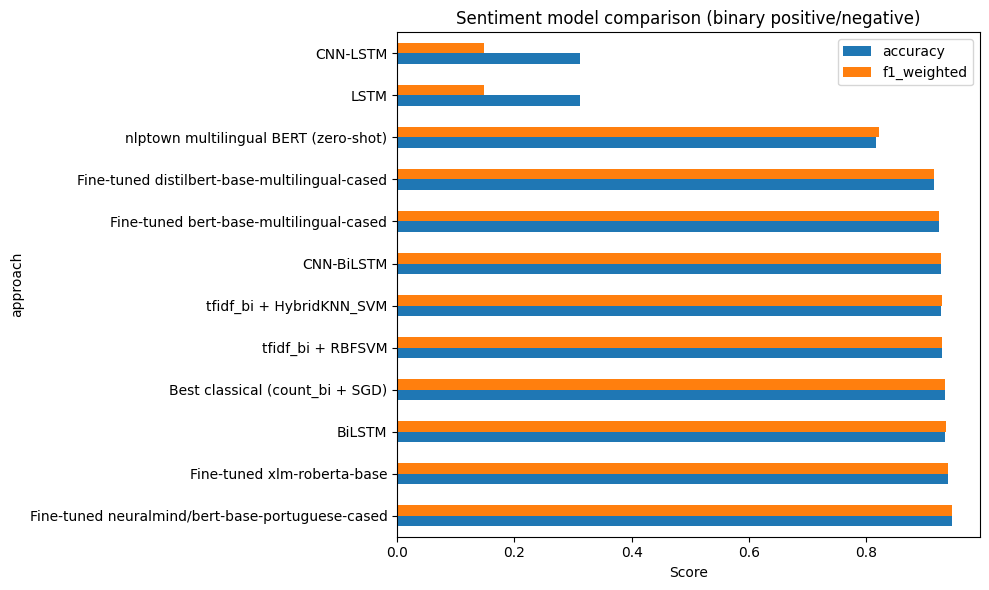

In [16]:
comparison = []

# classical best
comparison.append({
    "approach": f"Best classical ({best_vec_name} + {best_name})",
    "accuracy": accuracy_score(y_test, pred_best_classical),
    "f1_weighted": f1_score(y_test, pred_best_classical, average="weighted"),
    "notes": "IJIEEB-style ML suite"
})

# explicitly surface RBF SVM and the Sarowar-style Hybrid KNN-SVM even when
# they aren't the single best classical model, since they're worth comparing
for clf_name, note in [("RBFSVM", "RBF-kernel SVM (subsampled)"),
                        ("HybridKNN_SVM", "Sarowar et al. (2019) KNN-cluster + SVM ensemble")]:
    sub = classical_df[classical_df["classifier"] == clf_name].sort_values("f1_weighted", ascending=False)
    if len(sub):
        row = sub.iloc[0]
        comparison.append({
            "approach": f"{row['vectorizer']} + {clf_name}",
            "accuracy": row["accuracy"],
            "f1_weighted": row["f1_weighted"],
            "notes": note
        })

# nlptown (on sample - report sample binary)
comparison.append({
    "approach": "nlptown multilingual BERT (zero-shot)",
    "accuracy": binary_acc,
    "f1_weighted": f1_score(sample["true_binary"].map({"negative":0,"positive":1}),
                            sample["pretrained_sentiment"].map({"negative":0,"positive":1}), average="weighted"),
    "notes": "Original notebook baseline; evaluated on sample"
})

# every fine-tuned transformer backbone
for name, r in transformer_ft_results.items():
    comparison.append({
        "approach": f"Fine-tuned {name}",
        "accuracy": r["accuracy"],
        "f1_weighted": r["f1_weighted"],
        "notes": "STI 2022-style fine-tune"
    })

# DL sequence models (LSTM / BiLSTM / CNN-LSTM / CNN-BiLSTM)
for _, row in dl_df.iterrows():
    comparison.append({
        "approach": row["model"],
        "accuracy": row["accuracy"],
        "f1_weighted": row["f1_weighted"],
        "notes": "Keras sequence model (STI 2022 style)"
    })

# de-dupe: if any cell above is re-run, keep only the first (freshest) row
# per approach name instead of accumulating repeats
comparison_df = (pd.DataFrame(comparison)
                  .drop_duplicates(subset=["approach"], keep="first")
                  .sort_values("f1_weighted", ascending=False)
                  .reset_index(drop=True))
print(comparison_df.to_string())

# bar plot
fig, ax = plt.subplots(figsize=(10, 6))
comparison_df.plot.barh(x="approach", y=["accuracy", "f1_weighted"], ax=ax)
ax.set_xlabel("Score")
ax.set_title("Sentiment model comparison (binary positive/negative)")
plt.tight_layout()
plt.show()


## 8. Auto-Flag Negative Reviews for Customer Service
Run the best classical model over **all** written reviews and produce a priority queue for CS agents.


In [17]:
all_reviews_text = reviews.dropna(subset=["review_comment_message"]).copy()
all_reviews_text["review_comment_message"] = all_reviews_text["review_comment_message"].str.strip()
all_reviews_text = all_reviews_text[all_reviews_text["review_comment_message"].str.len() > 0]
all_reviews_text["full_text"] = (
    all_reviews_text["review_comment_title"].fillna("") + " " + all_reviews_text["review_comment_message"]
).str.strip()

# score with best classical pipeline
X_all = best_vec.transform(all_reviews_text["full_text"])
if hasattr(best_clf, "predict_proba"):
    proba_neg = best_clf.predict_proba(X_all)[:, 0]   # class 0 = negative
else:
    # LinearSVC / some models lack predict_proba → use decision_function
    dec = best_clf.decision_function(X_all)
    proba_neg = 1 / (1 + np.exp(dec))   # rough sigmoid of distance to positive side

all_reviews_text["pred_sentiment"] = best_clf.predict(X_all)
all_reviews_text["pred_label"] = all_reviews_text["pred_sentiment"]
all_reviews_text["neg_confidence"] = proba_neg

cs_queue = (all_reviews_text[all_reviews_text["pred_label"] == 0]
            .sort_values("neg_confidence", ascending=False)
            [["review_id", "order_id", "review_score", "full_text", "neg_confidence"]]
            .head(500))
print(f"CS negative-review queue (top 500 by confidence): {len(cs_queue)} rows")
print(cs_queue.head(10).to_string())


CS negative-review queue (top 500 by confidence): 500 rows
                              review_id                          order_id  review_score                                                                                                                                                                                                                                full_text  neg_confidence
48618  7e3a93130ae3a1a1345cd08073629232  938ae4cc3e41fb0e80467cbd9b3b0b32             1  Produto nÃ£o entregue Comprei um bebedouro dia 08/04 e me deram um prazo de atÃ© o dia 30/04 para me entregar, hj jÃ¡ sÃ£o 02/05 e nÃ£o me entregaram nÃ£o comprem nada vendido e entregue pela targaryen mando emails e nÃ£o respondem        1.000000
4392   0b7f1d51251cdd73346eed0296022fee  0499c7fe87611ea8ba76fc6ddceaad0e             1                              PÃ©ssimo! Produto errado Demorou para chegar e nÃ£o veio o produto que comprei. Produto mau embalado, Produto errado e NF dentro do produto em nome de

## 9. Category / Seller Sentiment Trend Dashboard
Link scored reviews back to product category and seller for operational insights.


Worst categories by predicted negative rate:
                               n_reviews  negative_rate  avg_score
product_category_name_english                                     
office_furniture                     604       0.473510   3.105960
air_conditioning                     102       0.421569   3.392157
agro_industry_and_commerce            59       0.406780   3.338983
home_construction                    192       0.401042   3.447917
fashion_male_clothing                 63       0.396825   3.222222
furniture_living_room                153       0.379085   3.516340
unknown                              602       0.378738   3.413621
market_place                         107       0.373832   3.570093
audio                                153       0.372549   3.424837
consoles_games                       395       0.369620   3.569620
computers_accessories               2692       0.368128   3.519688
baby                                1044       0.363985   3.543103
furniture_decor  

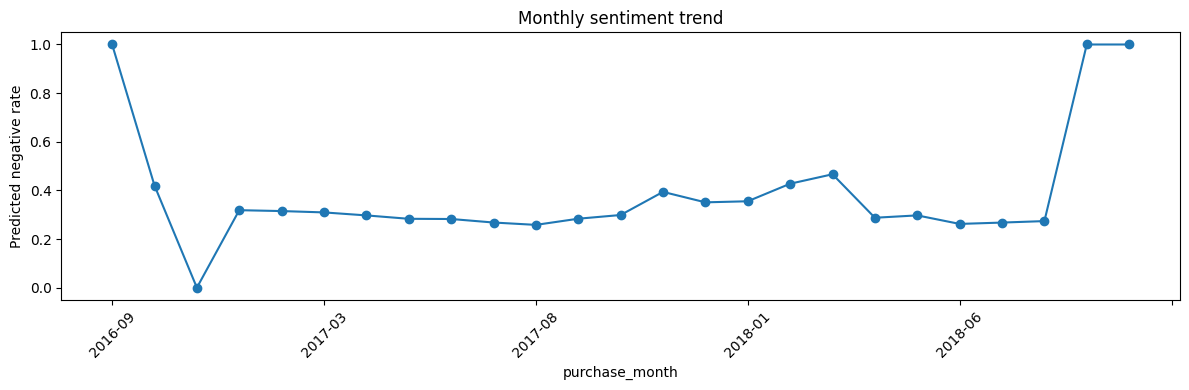

In [18]:
products = products.merge(cat_trans, on="product_category_name", how="left")
products["product_category_name_english"] = (
    products["product_category_name_english"]
    .fillna(products["product_category_name"])
    .fillna("unknown")
)

order_primary_item = (
    order_items.sort_values("price", ascending=False)
    .drop_duplicates("order_id")
    [["order_id", "product_id", "seller_id"]]
)

review_context = (all_reviews_text
    .merge(orders[["order_id", "customer_id", "order_purchase_timestamp"]], on="order_id", how="left")
    .merge(order_primary_item, on="order_id", how="left")
    .merge(products[["product_id", "product_category_name_english"]], on="product_id", how="left")
    .merge(sellers[["seller_id", "seller_state"]], on="seller_id", how="left")
)
review_context["purchase_month"] = review_context["order_purchase_timestamp"].dt.to_period("M").astype(str)
review_context["is_negative"] = (review_context["pred_label"] == 0).astype(int)

category_sentiment = (review_context
    .groupby("product_category_name_english")
    .agg(n_reviews=("review_id", "count"),
         negative_rate=("is_negative", "mean"),
         avg_score=("review_score", "mean"))
    .query("n_reviews >= 30")
    .sort_values("negative_rate", ascending=False)
)
print("Worst categories by predicted negative rate:")
print(category_sentiment.head(15).to_string())

seller_sentiment = (review_context
    .groupby("seller_id")
    .agg(n_reviews=("review_id", "count"),
         negative_rate=("is_negative", "mean"),
         avg_score=("review_score", "mean"))
    .query("n_reviews >= 20")
    .sort_values("negative_rate", ascending=False)
)
print("Worst sellers by predicted negative rate:")
print(seller_sentiment.head(15).to_string())

monthly_sentiment = (review_context
    .groupby("purchase_month")
    .agg(n_reviews=("review_id", "count"),
         negative_rate=("is_negative", "mean"))
    .sort_index()
)
fig, ax = plt.subplots(figsize=(12, 4))
monthly_sentiment["negative_rate"].plot(ax=ax, marker="o")
ax.set_ylabel("Predicted negative rate")
ax.set_title("Monthly sentiment trend")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [19]:
def predict_sentiment(text):
    """Score one review with the best classical model (count_bi + SGD)."""
    vec = best_vec.transform([text])
    pred = best_clf.predict(vec)[0]
    if hasattr(best_clf, "predict_proba"):
        proba = best_clf.predict_proba(vec)[0]
        pos_p, neg_p = proba[1], proba[0]
    else:
        dec = best_clf.decision_function(vec)[0]
        pos_p = 1 / (1 + np.exp(-dec))
        neg_p = 1 - pos_p
    label = "POSITIVE" if pred == 1 else "NEGATIVE"
    return {"label": label, "positive_pct": round(pos_p * 100, 1), "negative_pct": round(neg_p * 100, 1)}

# examples
print(predict_sentiment("Produto chegou inteiro e antes do prazo, muito bom, recomendo muito!"))
print(predict_sentiment("Chegou atrasado e veio quebrado, péssimo atendimento."))

{'label': 'POSITIVE', 'positive_pct': np.float64(99.9), 'negative_pct': np.float64(0.1)}
{'label': 'NEGATIVE', 'positive_pct': np.float64(9.4), 'negative_pct': np.float64(90.6)}


## 10. Try It Yourself
Edit the text below and re-run the cell. Portuguese works best (model trained on Olist reviews); English also works reasonably with the multilingual models.


In [20]:
your_review_text = "Produto chegou inteiro e antes do prazo, muito bom, recomendo muito!"

text_vec = best_vec.transform([your_review_text])
prediction = best_clf.predict(text_vec)[0]
if hasattr(best_clf, "predict_proba"):
    proba = best_clf.predict_proba(text_vec)[0]
    pos_p, neg_p = proba[1], proba[0]
else:
    dec = best_clf.decision_function(text_vec)[0]
    pos_p = 1 / (1 + np.exp(-dec))
    neg_p = 1 - pos_p

label = "POSITIVE" if prediction == 1 else "NEGATIVE"
print(f"Review text : {your_review_text}")
print(f"Prediction  : {label}")
print(f"Confidence  : Positive {pos_p*100:.1f}%  |  Negative {neg_p*100:.1f}%")


Review text : Produto chegou inteiro e antes do prazo, muito bom, recomendo muito!
Prediction  : POSITIVE
Confidence  : Positive 99.9%  |  Negative 0.1%


## 11. Save Artifacts

In [21]:
os.makedirs("/kaggle/working/models_sentiment", exist_ok=True)

joblib.dump(best_clf, "/kaggle/working/models_sentiment/best_classical_clf.pkl")
joblib.dump(best_vec, "/kaggle/working/models_sentiment/best_vectorizer.pkl")
classical_df.to_csv("/kaggle/working/models_sentiment/classical_results.csv", index=False)
comparison_df.to_csv("/kaggle/working/models_sentiment/all_approaches_comparison.csv", index=False)
cs_queue.to_csv("/kaggle/working/models_sentiment/cs_negative_review_queue.csv", index=False)
category_sentiment.to_csv("/kaggle/working/models_sentiment/category_sentiment_trend.csv")
seller_sentiment.to_csv("/kaggle/working/models_sentiment/seller_sentiment_trend.csv")

summary = {
    "best_classical": f"{best_vec_name} + {best_name}",
    "best_classical_f1": float(best_score),
    "nlptown_binary_acc": float(binary_acc),
    "best_finetuned_model": MODEL_NAME,
    "best_finetuned_acc": float(ft_acc),
    "best_finetuned_f1": float(ft_f1),
    "all_finetuned_transformers": {
        name: {"accuracy": float(r["accuracy"]), "f1_weighted": float(r["f1_weighted"])}
        for name, r in transformer_ft_results.items()
    },
    "dl_results": dl_results,
    "used_pretrained_fasttext": bool(embedding_matrix is not None),
    "duplicate_review_texts_dropped": int(n_before - n_after),
}
with open("/kaggle/working/models_sentiment/summary.json", "w") as f:
    json.dump(summary, f, indent=2)

print("Saved to /kaggle/working/models_sentiment/")
!ls -la /kaggle/working/models_sentiment


Saved to /kaggle/working/models_sentiment/
total 1384
drwxr-xr-x 2 root root   4096 Aug 19 06:21 .
drwxr-xr-x 4 root root   4096 Aug 19 06:21 ..
-rw-r--r-- 1 root root   1184 Aug 19 06:21 all_approaches_comparison.csv
-rw-r--r-- 1 root root 241111 Aug 19 06:21 best_classical_clf.pkl
-rw-r--r-- 1 root root 975523 Aug 19 06:21 best_vectorizer.pkl
-rw-r--r-- 1 root root   3217 Aug 19 06:21 category_sentiment_trend.csv
-rw-r--r-- 1 root root   2302 Aug 19 06:21 classical_results.csv
-rw-r--r-- 1 root root 138769 Aug 19 06:21 cs_negative_review_queue.csv
-rw-r--r-- 1 root root  29381 Aug 19 06:21 seller_sentiment_trend.csv
-rw-r--r-- 1 root root   1367 Aug 19 06:21 summary.json


## 12. Summary

**What changed vs the original notebook**
- Freight-cost formula reconstruction completely removed.
- Only sentiment analysis remains.
- Added the full classical ML grid used by Shanto et al. (IJIEEB 2023): LR, RF, LinearSVM, **RBF SVM**, MNB, SGD, DT, KNN × TF-IDF/Count (uni & bi-gram).
- Added the **Sarowar et al. (2019) Hybrid KNN-cluster + SVM** ensemble as a custom scikit-learn-compatible estimator (`HybridKNNSVM`).
- Added **CNN-BiLSTM** alongside LSTM / BiLSTM / CNN-LSTM, following Sarker et al. (STI 2022).
- Added **pretrained Portuguese fastText embeddings** (`cc.pt.300.vec`) to initialize the Keras `Embedding` layer, with an automatic fallback to a learned embedding if the download isn't available.
- Fine-tunes **four transformer backbones** instead of one: DistilBERT-multilingual (original baseline), `xlm-roberta-base`, `bert-base-multilingual-cased` (m-BERT), and `neuralmind/bert-base-portuguese-cased` (BERTimbau, Portuguese-specific).
- Kept the original zero-shot `nlptown` star model, CS negative-review queue, and category/seller trend dashboards.

**Duplicate / data-leakage safeguards added**
- Exact-duplicate review texts are dropped **before** the train/test split, and an assertion confirms zero text overlap between the two partitions afterward.
- `classifiers` and `vectorizers` dictionaries are asserted to contain no duplicate keys, so no model is accidentally trained twice under the same name.
- The Keras `Tokenizer` and the fastText embedding lookup are both built from `X_train` only — never from the test set.
- Transformer fine-tuning subsamples are drawn from `X_train`/`y_train` only; the held-out `X_test`/`y_test` is untouched until final evaluation.
- `FT_MODEL_NAMES` is de-duplicated with `dict.fromkeys()` before the fine-tuning loop, and `MODEL_BUILDERS` / `classifiers` are asserted unique, so re-running cells can't silently double-count a model.
- `classical_df`, `dl_df`, and `comparison_df` are all explicitly `drop_duplicates()`-ed by their key column, so re-running upstream cells never produces repeated rows in a results table.

**Expected behaviour on Olist Portuguese reviews**
- Classical TF-IDF + LR / LinearSVM / RF usually land in the high 80s–low 90s binary accuracy; RBF SVM and the Hybrid KNN-SVM ensemble are worth comparing against those but are typically similar or slightly behind on a dataset this size (unlike Sarowar et al.'s smaller Bangla corpus, where clustering helped more).
- Fine-tuned transformers and well-tuned BiLSTM/CNN-BiLSTM models typically match or slightly exceed the classical baseline; among the four backbones, `xlm-roberta-base` and BERTimbau (Portuguese-specific) are the best candidates to beat DistilBERT-multilingual.
- Because the label is derived from text that already exists, these numbers are far more reliable than any "predict delay / cancellation" model.

**How to go further**
- Increase `FT_SIZE` / epochs for a closer reproduction of Sarker et al.'s full fine-tuning setup.
- Add Portuguese-specific stop-word lists (Sarowar-style) before vectorization.
- Ensemble the best classical model with the best fine-tuned transformer.
- Try more `n_clusters` values for `HybridKNNSVM`, or swap its per-cluster kernel from `linear` to `rbf`.
